##### Importar datos

In [2]:
import pandas as pd
# Especifica la ruta completa de tu archivo CSV
file_path = r"C:\Users\shara\OneDrive - Universidad Autónoma Latinoamericana\7mo semestre\Ciencia de datos II\heart.csv"
# Cargar el archivo CSV en un DataFrame
data = pd.read_csv(file_path)
# Mostrar las primeras filas del DataFrame para verificar que se ha cargado correctamente
print(data.head())
data.dtypes

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

### EDA

##### Diccionario de datos

1) **cp (chest pain type):** Tipo de dolor en el pecho. Este valor indica el tipo de dolor que experimenta el paciente:

- 0: Angina típica (dolor en el pecho relacionado con el corazón).

- 1: Angina atípica (dolor en el pecho que no se ajusta a una categoría clara).

- 2: Dolor no anginoso (dolor en el pecho no relacionado con el corazón).

- 3: Asintomático (no hay dolor, la persona no presenta síntomas).

2) **fbs (fasting blood sugar > 120 mg/dl):** Azúcar en sangre en ayunas superior a 120 mg/dl. Indica si el nivel de azúcar en sangre en ayunas es mayor de 120 mg/dl:

- 1: Verdadero (sí, el nivel de azúcar en ayunas es mayor de 120 mg/dl).

- 0: Falso (no, el nivel de azúcar en ayunas no es mayor de 120 mg/dl).

3) **restecg (resting electrocardiographic results):** Resultados del electrocardiograma en reposo. Muestra el estado del corazón en un examen de ECG realizado mientras el paciente está en reposo:

- 0: Normal (el ECG muestra un patrón normal).

- 1: Anomalía en la onda ST-T (esto incluye inversiones en la onda T y/o elevación o depresión del segmento ST superior a 0.05 mV).

- 2: Hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes (esto indica que hay un aumento en el tamaño del ventrículo izquierdo, lo que podría sugerir hipertensión o problemas cardíacos).

4) **thalach (maximum heart rate achieved):** Máxima frecuencia cardíaca alcanzada. Es la frecuencia cardíaca más alta que el paciente logró alcanzar durante una prueba de ejercicio.

5) **exang (exercise induced angina):** Angina inducida por ejercicio. Indica si el paciente experimentó dolor en el pecho debido al ejercicio:

- 1: Sí (experimentó angina durante el ejercicio).

- 0: No (no experimentó angina durante el ejercicio).

6) **oldpeak:** Depresión del segmento ST inducida por ejercicio en relación con el descanso. El segmento ST es una parte del ECG que puede ser afectada por enfermedades cardíacas. Si hay una depresión (bajada) del segmento ST durante el ejercicio, puede indicar problemas en el corazón.

7) **slope (the slope of the peak exercise ST segment):** La pendiente del segmento ST máximo durante el ejercicio. Este valor describe cómo se comporta el segmento ST en su punto más alto durante el ejercicio:

- 0: Pendiente ascendente (el segmento ST sube durante el ejercicio).

- 1: Pendiente plana (el segmento ST se mantiene plano durante el ejercicio).

2: Pendiente descendente (el segmento ST baja durante el ejercicio, lo que puede ser un indicio de problemas cardíacos).

8) **ca (number of major vessels colored by fluoroscopy):** Número de vasos principales coloreados por fluoroscopia. Indica cuántos vasos sanguíneos importantes del corazón son visibles en un examen de fluoroscopia:

Los valores van de 0 a 3, siendo 0 cuando no hay vasos visibles, y 3 cuando se pueden ver tres vasos principales.

9) **thal:** Esto indica el estado de la imagen de los vasos del corazón en la fluoroscopia:

- 0: Error (en el conjunto de datos original, esto se asignaba a valores NaN, lo que significa que no había información disponible).

- 1: Defecto fijo (una área del corazón muestra una obstrucción permanente).

- 2: Normal (no hay obstrucción en el corazón).

- 3: Defecto reversible (hay una obstrucción que podría ser tratada o corregida).

10) **target (the label):** Este es el diagnóstico de la enfermedad cardíaca basado en la angiografía, que mide el estrechamiento de las arterias:

- 0: No hay enfermedad (menos del 50% de estrechamiento en las arterias).

- 1: Enfermedad (más del 50% de estrechamiento en las arterias).
11) age: Edad en años
12) sex: Género del individuo
1 = Hombre
0 = Mujer

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#### Limpieza de datos

In [4]:
# Filtrar valores incorrectos
data = data[data['ca'] < 4]      # eliminar valores erróneos en 'ca'
data = data[data['thal'] > 0]    # eliminar valores erróneos en 'thal'

In [5]:
# Características numéricas
num_feats = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']
# Características binarias (0 o 1)
bin_feats = ['sex', 'fbs', 'exang', 'target']
# Características categóricas (con múltiples categorías)
nom_feats = ['cp', 'restecg', 'slope', 'thal']
# Combinamos las características categóricas binarias y las categóricas de múltiples valores
cat_feats = nom_feats + bin_feats

# Imprimir las categorías de características para verificar
print("Características numéricas:", num_feats)
print("Características binarias:", bin_feats)
print("Características categóricas:", nom_feats)
print("Todas las características categóricas:", cat_feats)

Características numéricas: ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']
Características binarias: ['sex', 'fbs', 'exang', 'target']
Características categóricas: ['cp', 'restecg', 'slope', 'thal']
Todas las características categóricas: ['cp', 'restecg', 'slope', 'thal', 'sex', 'fbs', 'exang', 'target']


#### Estadísticas descriptivas ####

In [6]:
data[num_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
chol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
trestbps,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
thalach,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
oldpeak,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
ca,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


- Edad: En promedio 54 años, con rango entre 29 y 77 años
- Colesterol: Promedio de 246 mg/dl, con valores extremos de 126 a 564 mg/dl
- Presión arterial en reposo: Promedio de 132 mmHg, valores entre 94 y 200 mmHg
- Frecuencia cardíaca máxima: Promedio de 150 latidos/min, entre 71 y 202 latidos/min
- Depresión del segmento ST: Promedio de 1.04, con rango entre 0 y 6.2
- Número de vasos principales: La mayoría de pacientes tienen 0 (la mediana es 0), con un máximo de 4

C:\Users\shara\AppData\Local\Temp\ipykernel_18672\3187927058.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data['target'], palette=mypal)
C:\Users\shara\AppData\Local\Temp\ipykernel_18672\3187927058.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.countplot(x=data['target'], palette=mypal)
C:\Users\shara\AppData\Local\Temp\ipykernel_18672\3187927058.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin enfermedad', 'Con enfermedad'])


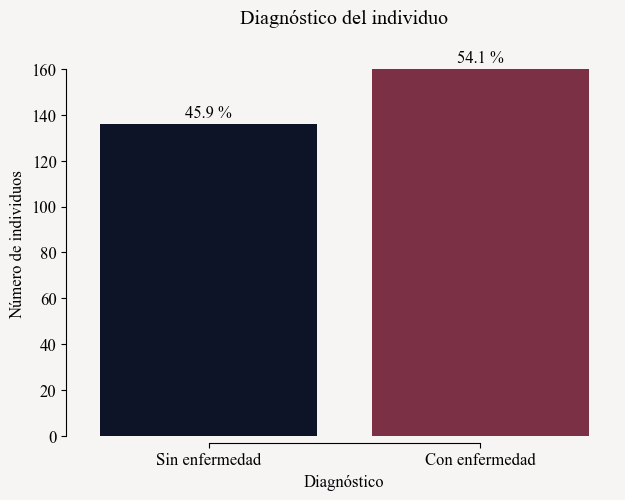

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer la fuente predeterminada en Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Usar tu nueva paleta de colores
mypal = ['#09122C', '#872341', '#BE3144', '#E17564']

plt.figure(figsize=(7, 5), facecolor='#F6F5F4')
total = float(len(data))

# Gráfico de barras para la variable 'target' con tus nuevos colores
ax = sns.countplot(x=data['target'], palette=mypal)
ax.set_facecolor('#F6F5F4')

# Añadir porcentaje en cada barra (sin caja)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f} %'.format((height/total)*100),
            ha="center")

# Cambiar etiquetas del eje x
ax.set_xticklabels(['Sin enfermedad', 'Con enfermedad'])
ax.set_title('Diagnóstico del individuo', y=1.05)
ax.set_xlabel('Diagnóstico')
ax.set_ylabel('Número de individuos')

sns.despine(right=True)
sns.despine(offset=5, trim=True)


#### Observación de caracteristicas numéricas ####

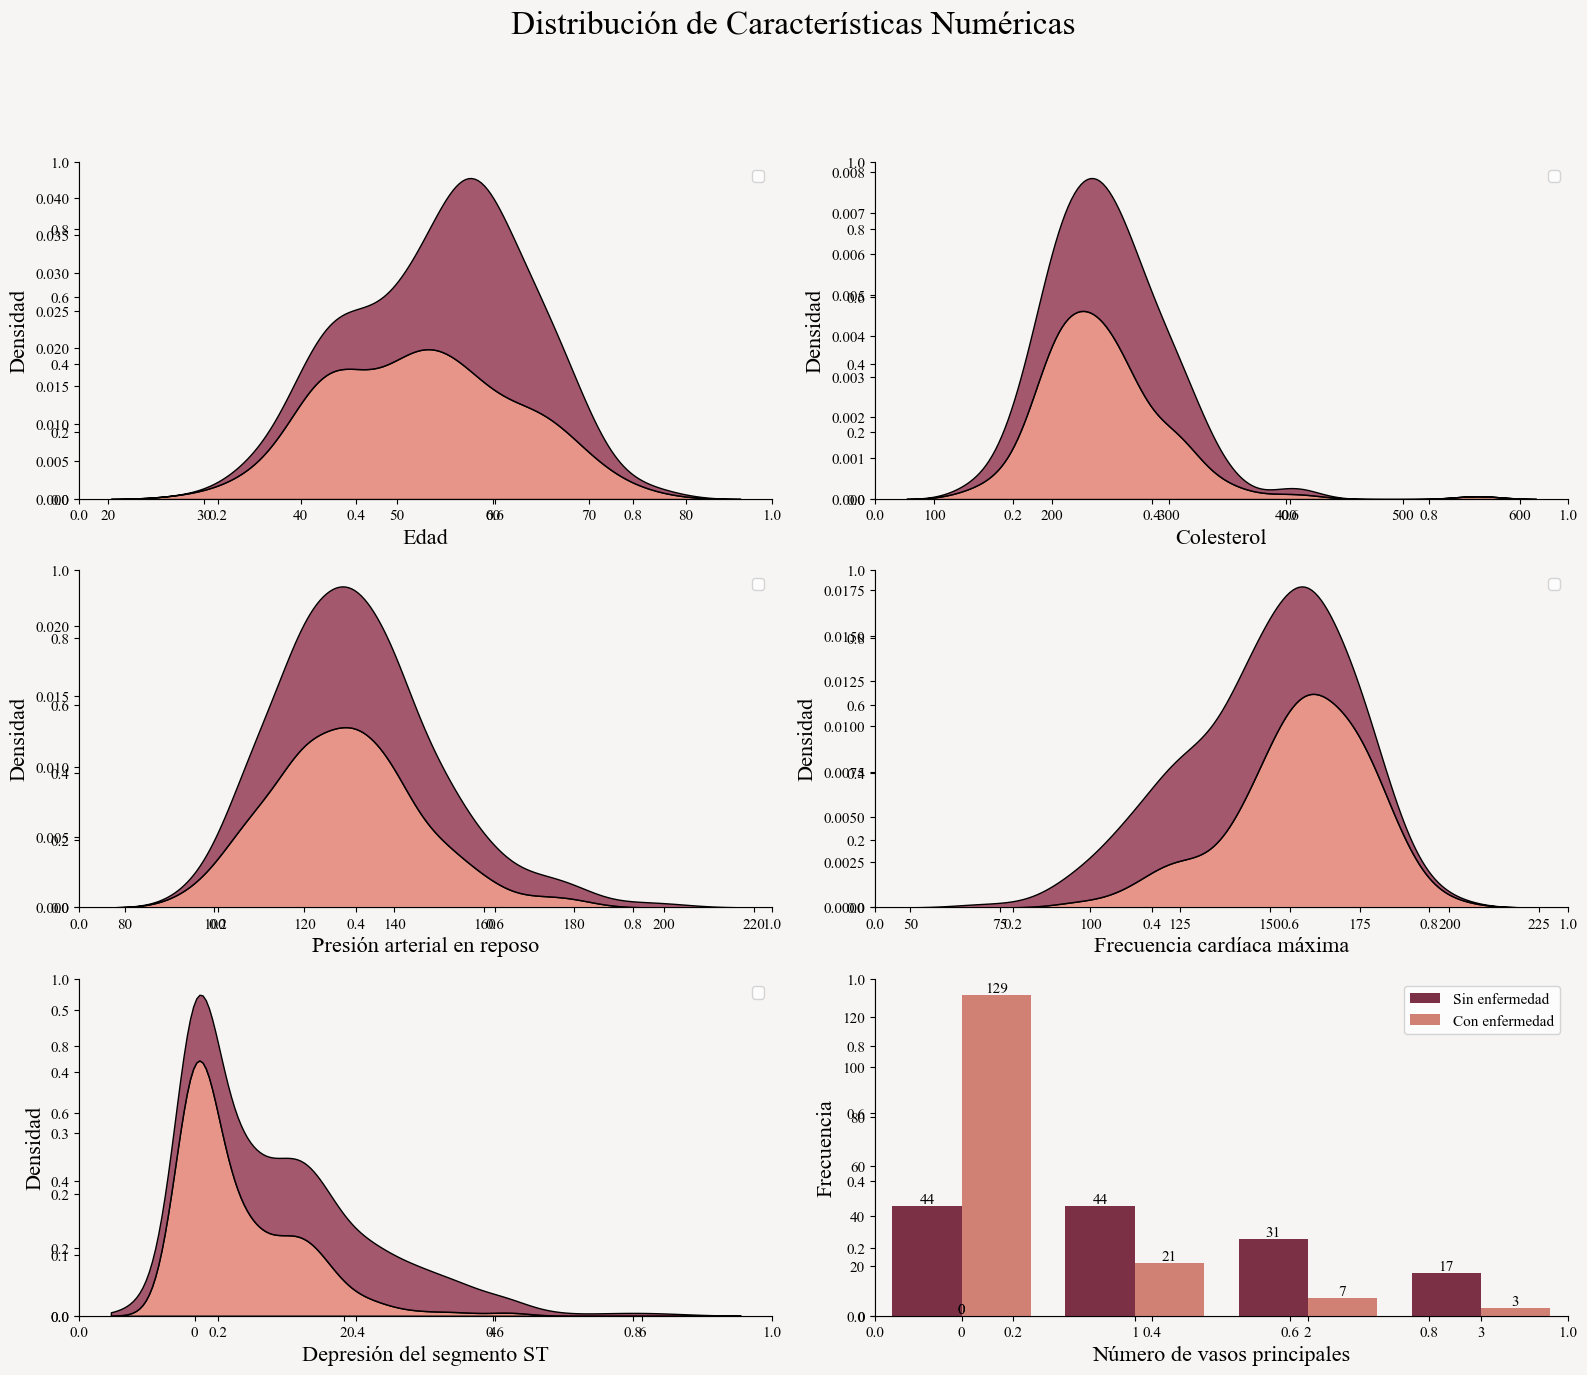

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer la fuente predeterminada en Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Usar la paleta de colores definida
mypal = ['#09122C', '#872341', '#BE3144', '#E17564']

# Características numéricas ya definidas
num_feats = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']
# Diccionario para traducir nombres de variables
nombres_variables = {
    'age': 'Edad',
    'chol': 'Colesterol',
    'trestbps': 'Presión arterial en reposo',
    'thalach': 'Frecuencia cardíaca máxima',
    'oldpeak': 'Depresión del segmento ST',
    'ca': 'Número de vasos principales'
}

L = len(num_feats)
ncol = 2
nrow = int(np.ceil(L/ncol))

fig, ax = plt.subplots(nrow, ncol, figsize=(16, 14), facecolor='#F6F5F4')   
fig.subplots_adjust(top=0.92)

i = 1
for col in num_feats:
    plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
    
    # Para casi todas las variables, usar kdeplot
    if col != 'ca':
        ax = sns.kdeplot(data=data, x=col, hue="target", multiple="stack", palette=[mypal[1], mypal[3]]) 
        ax.set_xlabel(nombres_variables[col], fontsize=16)
        ax.set_ylabel("Densidad", fontsize=16)
    # Para 'ca' (equivalente a num_major_vessels en tu código original)
    else:
        ax = sns.countplot(data=data, x=col, hue="target", palette=[mypal[1], mypal[3]])
        ax.set_xlabel(nombres_variables[col], fontsize=16)
        ax.set_ylabel("Frecuencia", fontsize=16)
        # Añadir números sobre las barras sin cajas de texto
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2., height + 1, '{:1.0f}'.format((height)), ha="center")
    
    # Configuración común para ambos tipos de gráficos
    sns.despine(right=True)
    sns.despine(offset=0, trim=False)
    
    # Añadir leyenda con etiquetas en español
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Sin enfermedad', 'Con enfermedad'])
    
    i = i + 1

plt.suptitle('Distribución de Características Numéricas', fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.92])

#### Observación de variables categóricas ####

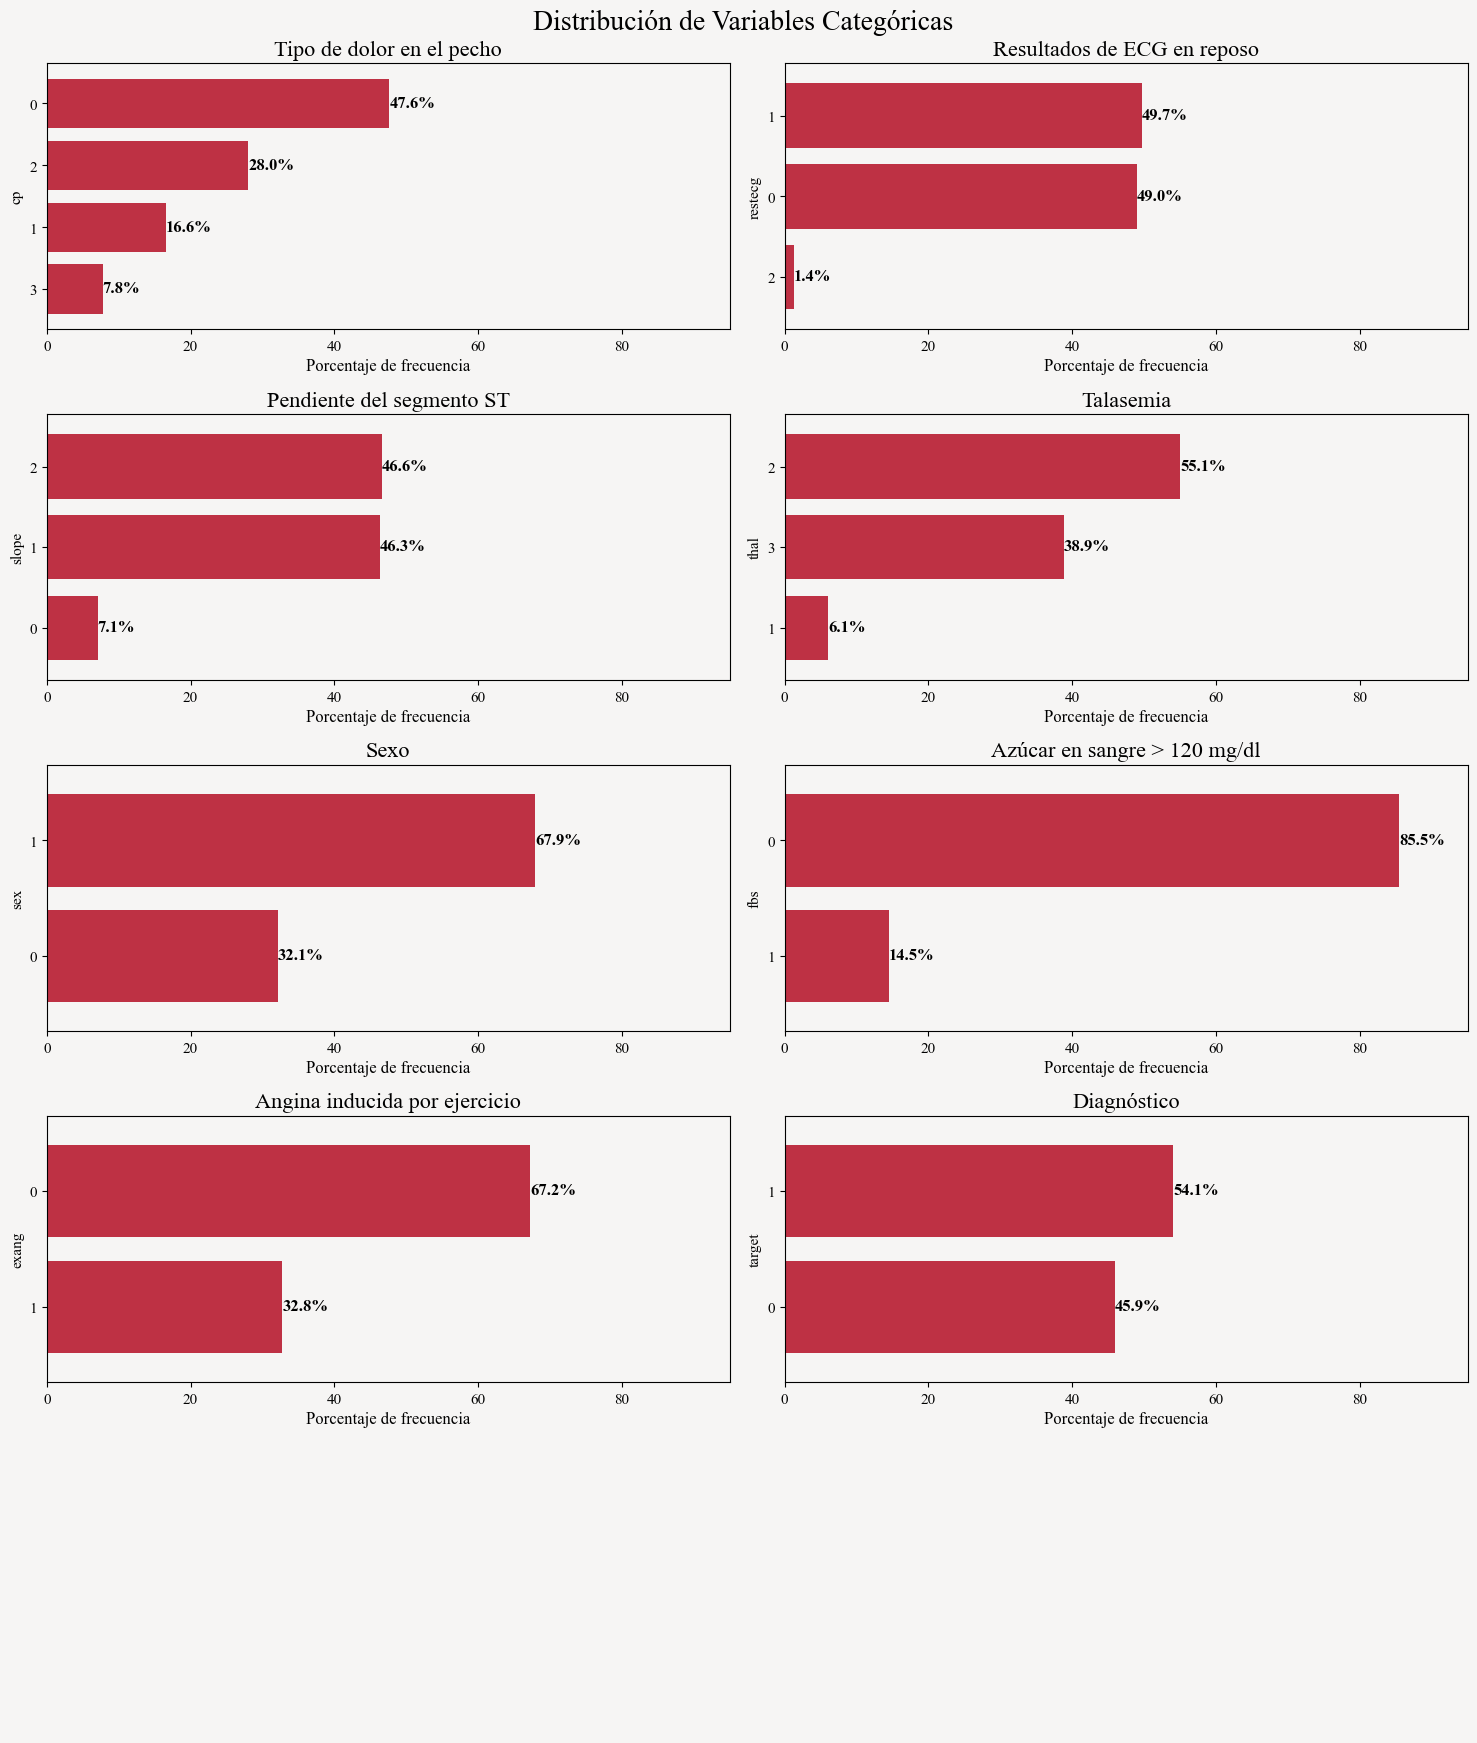

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer la fuente predeterminada en Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Usar la paleta de colores definida
mypal = ['#09122C', '#872341', '#BE3144', '#E17564']

# Características numéricas ya definidas
num_feats = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']

# Características categóricas (con múltiples categorías)
nom_feats = ['cp', 'restecg', 'slope', 'thal']
# Características binarias (0 o 1)
bin_feats = ['sex', 'fbs', 'exang', 'target']
# Todas las características categóricas
cat_feats = nom_feats + bin_feats

# Diccionario para traducir nombres de variables
nombres_variables = {
    'cp': 'Tipo de dolor en el pecho',
    'restecg': 'Resultados de ECG en reposo',
    'slope': 'Pendiente del segmento ST',
    'thal': 'Talasemia',
    'sex': 'Sexo',
    'fbs': 'Azúcar en sangre > 120 mg/dl',
    'exang': 'Angina inducida por ejercicio',
    'target': 'Diagnóstico'
}

# Crear el gráfico
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 18), facecolor='#F6F5F4')

# Loop para crear gráficos de barras para cada característica categórica
for i, col in enumerate(cat_feats):
    row = i // 2
    col_idx = i % 2
    
    # Calcular porcentajes de frecuencia
    value_counts = data[col].value_counts(normalize=True).mul(100).sort_values()
    
    # Crear gráfico de barras
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color=mypal[2])
    
    # Añadir porcentajes de frecuencia a las barras
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=12, weight='bold', va='center')
    
    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Porcentaje de frecuencia', fontsize=12)
    ax[row, col_idx].set_title(nombres_variables[col], fontsize=16)
    ax[row, col_idx].set_facecolor('#F6F5F4')

plt.suptitle('Distribución de Variables Categóricas', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.95)


total_plots = len(cat_feats)
for i in range(total_plots, 10):
    fig.axes[i].axis('off')


- **Género (sexo):** El conjunto de datos está compuesto predominantemente por hombres
- **Tipo de dolor torácico (cp):** El conjunto de datos muestra distintos tipos de dolor torácico entre los pacientes. El tipo 0 (angina típica) parece ser el más frecuente.
- **Glucemia en ayunas (fbs):** Una gran mayoría de los pacientes tiene niveles de glucemia en ayunas por debajo de 120 mg/dl, lo que indica que el azúcar en sangre elevada no es una condición común en este conjunto de datos.
- **Resultados del electrocardiograma en reposo (restecg):** Se observan diversos resultados en los electrocardiogramas en reposo, siendo algunos tipos más comunes que otros. La distribución exacta puede apreciarse en los gráficos.
- **Angina inducida por ejercicio (exang):** La mayoría de los pacientes no presenta angina inducida por el ejercicio, lo que sugiere que no es un síntoma frecuente entre los pacientes del conjunto de datos.
- **Pendiente del segmento ST durante el ejercicio (slope):** El conjunto de datos muestra diferentes pendientes del segmento ST durante el ejercicio. Un tipo específico podría ser más común, y su distribución puede inferirse a partir de los gráficos de barras.
- **Número de vasos principales coloreados por fluoroscopia (ca):** La mayoría de los pacientes tiene pocos vasos principales coloreados por fluoroscopia, siendo el valor '0' el más frecuente.
- **Resultado del test de esfuerzo con talio (thal):** El conjunto de datos presenta una variedad de resultados en la prueba de esfuerzo con talio. Un tipo particular parece ser el más prevalente, pero la distribución exacta se puede observar en los gráficos.
- **Presencia de enfermedad cardíaca (target):** El conjunto de datos está casi equilibrado en cuanto a la presencia de enfermedad cardíaca, con aproximadamente un 54.5% de los pacientes con la enfermedad y un 45.5% sin ella.

### Preprocesamiento

In [10]:

# Observar outliers
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# Calcular el primer cuartil (Q1) y tercer cuartil (Q3)
Q1 = data[continuous_features].quantile(0.25)
Q3 = data[continuous_features].quantile(0.75)

# Calcular el IQR
IQR = Q3 - Q1

# Identificar los outliers
outliers_count_specified = ((data[continuous_features] < (Q1 - 1.5 * IQR)) | (data[continuous_features] > (Q3 + 1.5 * IQR))).sum()

print(outliers_count_specified)



age         0
trestbps    9
chol        5
thalach     1
oldpeak     5
dtype: int64


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.stats import boxcox
import pandas as pd
import numpy as np

#

# Dividir el conjunto de datos en características (X) y la variable objetivo (y)
X = data.drop('target', axis=1)
y = data['target']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Definir las variables continuas y categóricas
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['cp', 'restecg', 'thal', 'sex', 'fbs', 'exang', 'slope', 'ca']

# 2. Crear transformadores para cada tipo de característica

# Transformador para características continuas (Box-Cox y escalado) 
  #Los outliers suelen generar distribuciones sesgadas, especialmente cuando están muy alejados de la media. Box-Cox ajusta la distribución para hacerla más simétrica. Si los datos tienen un sesgo hacia valores grandes, Box-Cox puede reducir esa asimetría y hacer que los datos se distribuyan de manera más uniforme. 
  # Al reducir el sesgo, los outliers se comprimen dentro de un rango más cercano a la media, lo que reduce su influencia en el modelo.
  
class BoxCoxTransformer:
    def fit(self, X, y=None):
        self.lambdas = {}
        for col in continuous_features:
            if X[col].min() > 0:  # Asegurarse de que los datos sean positivos
                self.lambdas[col] = boxcox(X[col])[1]  # Guardar el lambda de Box-Cox
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in continuous_features:
            if X_transformed[col].min() > 0:
                X_transformed[col] = boxcox(X_transformed[col], lmbda=self.lambdas.get(col, 0))
        return X_transformed

# Para las características categóricas: OneHotEncoding
  #Los modelos de machine learning no pueden trabajar directamente con variables categóricas en su forma original (como texto o etiquetas), ya que solo pueden manejar números. 
  # Por lo tanto, se aplica one hot encoding, para crear una nueva columna para cada categoría única en la variable original. 
  # Para cada fila del conjunto de datos, se asigna un 1 en la columna correspondiente a la categoría a la que pertenece la observación y 0 en las demás columnas. Esto elimina cualquier orden implícito y convierte las categorías en una representación numérica.
  
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesamiento de columnas continuas y categóricas usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', Pipeline([
            ('boxcox', BoxCoxTransformer()),
            ('scaler', StandardScaler())
        ]), continuous_features),
        ('categorical', categorical_transformer, categorical_features)
    ])




#### Observar Box-Cox

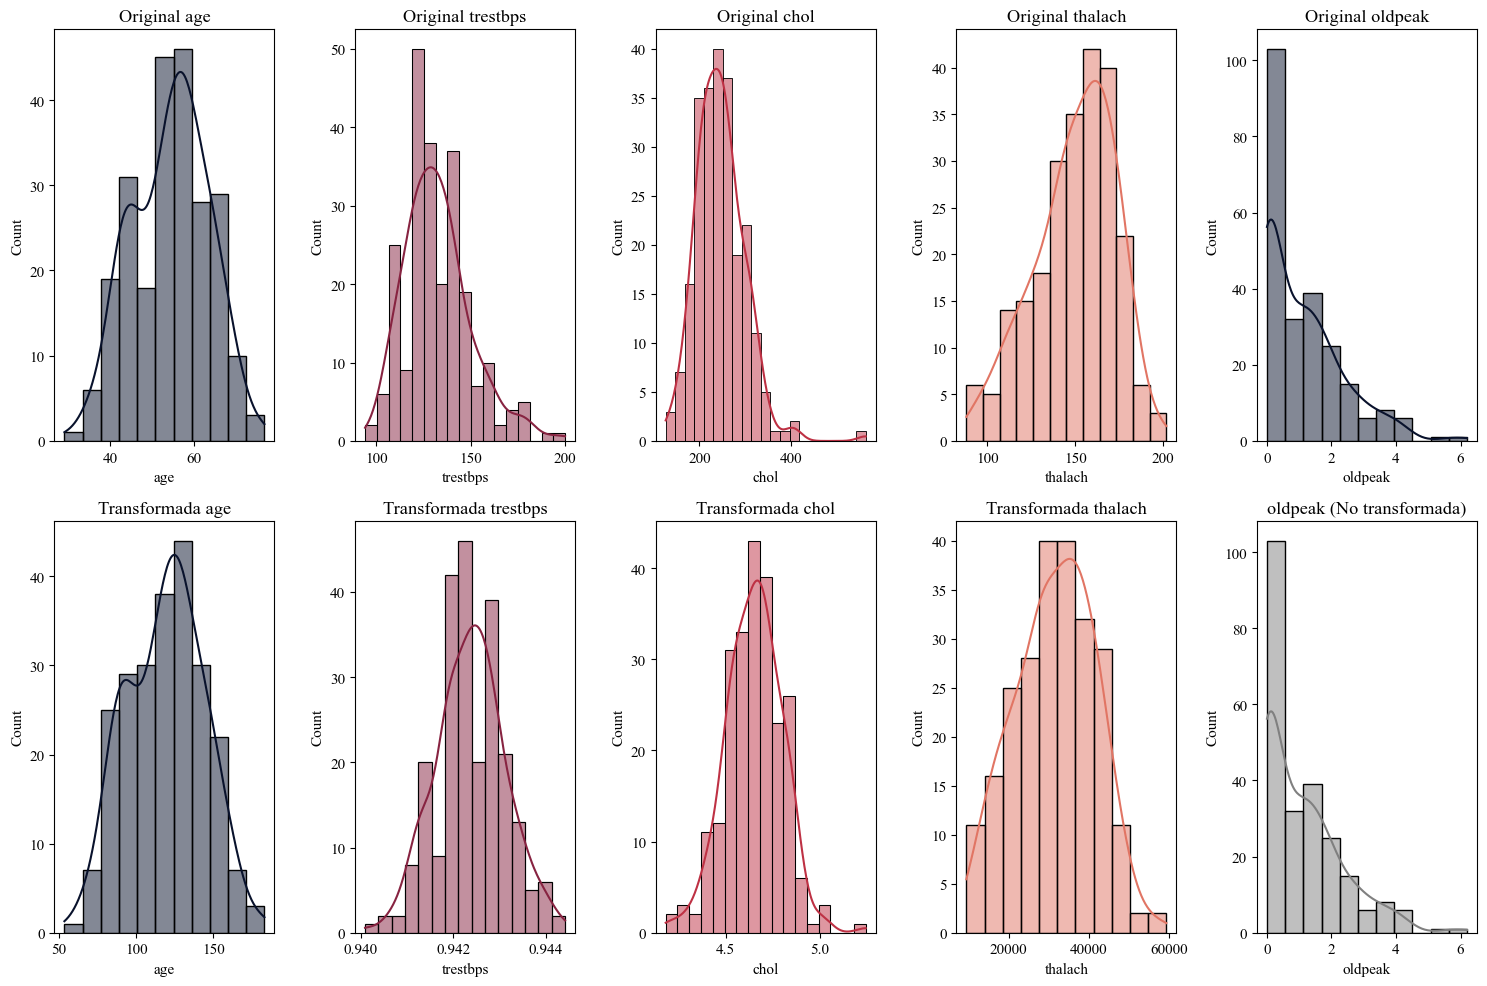

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

# Asegúrate de que las variables continuas sean estrictamente positivas
# para evitar errores al aplicar Box-Cox (añadiendo un pequeño valor si es necesario)
variables_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Colores personalizados para los gráficos
colores_personalizados = ['#09122C', '#872341', '#BE3144', '#E17564', '#09122C']

# Configurar el gráfico
fig, ax = plt.subplots(2, 5, figsize=(15, 10))

# Visualización de las distribuciones originales
for i, col in enumerate(variables_continuas):
    sns.histplot(X_train[col], kde=True, ax=ax[0, i], color=colores_personalizados[i % len(colores_personalizados)]).set_title(f'Original {col}')

# Aplicar Box-Cox y visualizar la distribución transformada
lambdas = {}
for i, col in enumerate(variables_continuas):
    if X_train[col].min() > 0:
        # Transformar la variable en el conjunto de entrenamiento
        X_train[col], lambdas[col] = boxcox(X_train[col])
        
        # Graficar la distribución transformada
        sns.histplot(X_train[col], kde=True, ax=ax[1, i], color=colores_personalizados[i % len(colores_personalizados)]).set_title(f'Transformada {col}')
    else:
        # Si no se transforma, mostrar la distribución original
        sns.histplot(X_train[col], kde=True, ax=ax[1, i], color='gray').set_title(f'{col} (No transformada)')

# Ajustar la disposición de los subgráficos
fig.tight_layout()
plt.show()


<!--  -->

### Modelos

##### Árbol de decisión

In [32]:
from sklearn.model_selection import StratifiedKFold
# Función para ajustar hiperparámetros maximizando el recall
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    clf_grid.fit(X_train, y_train)
    best_hyperparameters = clf_grid.best_params_
    return clf_grid.best_estimator_, best_hyperparameters

# Definir modelo base para Árbol de Decisión
dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Grid de hiperparámetros
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

# Aplicar tuning (con preprocesamiento incluido dentro del pipeline)
tree_pipeline_tune = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dt_base)
])

# Ajuste de hiperparámetros para el pipeline (nota que 'classifier__' se antepone a los nombres)
param_grid_dt_pipeline = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [2, 3, 4, 5],
    'classifier__min_samples_split': [2, 3, 4],
    'classifier__min_samples_leaf': [1, 2]
}

best_tree_model, best_tree_params = tune_clf_hyperparameters(tree_pipeline_tune, param_grid_dt_pipeline, X_train, y_train)
print("Mejores hiperparámetros para Árbol de Decisión:", best_tree_params)

# Evaluación del modelo optimizado
y_pred_best_tree = best_tree_model.predict(X_test)
print("\nEvaluación del Árbol de Decisión optimizado:")
print(classification_report(y_test, y_pred_best_tree, zero_division=0))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_best_tree))
print("ROC-AUC Árbol de Decisión optimizado:", roc_auc_score(y_test, best_tree_model.predict_proba(X_test)[:, 1]))


Mejores hiperparámetros para Árbol de Decisión: {'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}

Evaluación del Árbol de Decisión optimizado:
              precision    recall  f1-score   support

           0       0.78      0.64      0.71        28
           1       0.73      0.84      0.78        32

    accuracy                           0.75        60
   macro avg       0.76      0.74      0.74        60
weighted avg       0.75      0.75      0.75        60

Matriz de confusión:
 [[18 10]
 [ 5 27]]
ROC-AUC Árbol de Decisión optimizado: 0.7739955357142857


#### KNN

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. Crear pipeline: estandarizar + KNN
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Definir los hiperparámetros a evaluar
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. GridSearchCV con validación cruzada
grid_knn = GridSearchCV(pipeline_knn, param_grid, cv=5, scoring='f1_macro')
grid_knn.fit(X_train, y_train)

# 4. Resultados
print("Mejores hiperparámetros para KNN:")
print(grid_knn.best_params_)

# 5. Evaluación
print("\nEvaluación en los datos de entrenamiento:")
y_train_pred = grid_knn.predict(X_train)
print(classification_report(y_train, y_train_pred))

print("\nEvaluación en los datos de prueba:")
y_test_pred = grid_knn.predict(X_test)
print(classification_report(y_test, y_test_pred))


Mejores hiperparámetros para KNN:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}

Evaluación en los datos de entrenamiento:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       128

    accuracy                           1.00       236
   macro avg       1.00      1.00      1.00       236
weighted avg       1.00      1.00      1.00       236


Evaluación en los datos de prueba:
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        28
           1       0.83      0.78      0.81        32

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



##### Regresión logística

In [45]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# Definir el pipeline
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, class_weight='balanced')) # 'balanced' puede ayudar con desbalance
])

# Ampliar el grid de hiperparámetros
logreg_param_grid_expanded = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'logreg__penalty': ['l1', 'l2', 'elasticnet', None],
    'logreg__l1_ratio': [0, 0.5, 1], # Solo para 'elasticnet'
    'logreg__max_iter': [100, 200, 300]
}

# Ajuste de hiperparámetros con GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_logreg = GridSearchCV(logreg_pipeline, logreg_param_grid_expanded, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_logreg.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_logreg_expanded = grid_logreg.best_estimator_
best_logreg_hyperparams_expanded = grid_logreg.best_params_
print('Mejores hiperparámetros (búsqueda ampliada) para Regresión Logística: \n', best_logreg_hyperparams_expanded)

# Evaluación del modelo optimizado (búsqueda ampliada) en los datos de prueba
print("\nEvaluación del modelo de Regresión Logística (búsqueda ampliada) en los datos de prueba:")
y_pred_best_logreg_expanded = best_logreg_expanded.predict(X_test)
print(classification_report(y_test, y_pred_best_logreg_expanded, zero_division=0)) # Manejar división por cero

y_prob_best_logreg_expanded = best_logreg_expanded.predict_proba(X_test)[:, 1]
auc_best_logreg_expanded = roc_auc_score(y_test, y_prob_best_logreg_expanded)
print("ROC-AUC Regresión Logística optimizada (búsqueda ampliada):", auc_best_logreg_expanded)

Mejores hiperparámetros (búsqueda ampliada) para Regresión Logística: 
 {'logreg__C': 0.1, 'logreg__l1_ratio': 0.5, 'logreg__max_iter': 100, 'logreg__penalty': 'elasticnet', 'logreg__solver': 'saga'}

Evaluación del modelo de Regresión Logística (búsqueda ampliada) en los datos de prueba:
              precision    recall  f1-score   support

           0       0.47      1.00      0.64        28
           1       0.00      0.00      0.00        32

    accuracy                           0.47        60
   macro avg       0.23      0.50      0.32        60
weighted avg       0.22      0.47      0.30        60

ROC-AUC Regresión Logística optimizada (búsqueda ampliada): 0.6562500000000001


#### Comparación de los modelos

AUC-ROC Árbol de Decisión: 0.7740
AUC-ROC KNN: 0.8544
AUC-ROC Regresión Logística: 0.5000


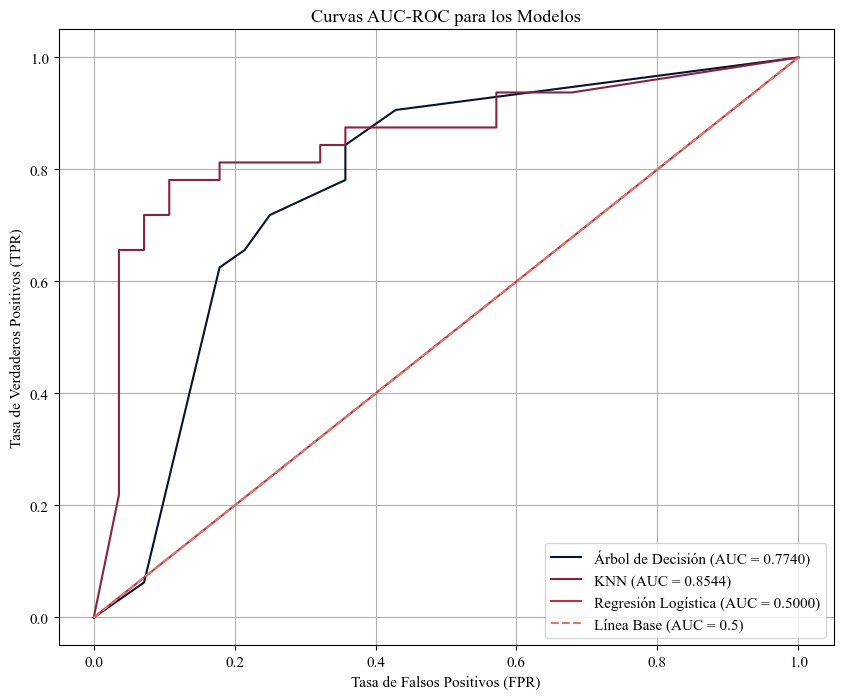

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Paleta de colores
colors = ['#09122C', '#872341', '#BE3144', '#E17564']

# Obtener las probabilidades de predicción en el conjunto de prueba

# Árbol de Decisión
y_prob_tree = best_tree_model.predict_proba(X_test)[:, 1]
auc_tree = roc_auc_score(y_test, y_prob_tree)

# KNN
y_prob_knn = grid_knn.predict_proba(X_test)[:, 1]
auc_knn = roc_auc_score(y_test, y_prob_knn)

# Regresión Logística
y_prob_logreg = best_logreg.predict_proba(X_test)[:, 1]
auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print(f"AUC-ROC Árbol de Decisión: {auc_tree:.4f}")
print(f"AUC-ROC KNN: {auc_knn:.4f}")
print(f"AUC-ROC Regresión Logística: {auc_logreg:.4f}")

# Paso 2: Calcular la curva ROC para cada modelo
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_prob_tree)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_prob_logreg)

# Paso 3: Graficar las curvas ROC con los colores especificados
plt.figure(figsize=(10, 8))
plt.plot(fpr_tree, tpr_tree, color=colors[0], label=f'Árbol de Decisión (AUC = {auc_tree:.4f})')
plt.plot(fpr_knn, tpr_knn, color=colors[1], label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot(fpr_logreg, tpr_logreg, color=colors[2], label=f'Regresión Logística (AUC = {auc_logreg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', color=colors[3], label='Línea Base (AUC = 0.5)') # Línea diagonal de referencia
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas AUC-ROC para los Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

El modelo KNN demostró el rendimiento superior en comparación con el Árbol de Decisión y la Regresión Logística para este conjunto de datos. El KNN logró la mayor exactitud (80%), puntuaciones F1 más equilibradas y altas para ambas clases (0.80 y 0.80), y el AUC-ROC más alto (0.852), lo que indica una excelente capacidad para distinguir entre la presencia y ausencia de enfermedad cardíaca. El Árbol de Decisión mostró un rendimiento moderado, con una exactitud del 75% y un AUC-ROC de 0.774. Por otro lado, el modelo de Regresión Logística, a pesar de haber sido optimizado para el recall de la clase positiva en el conjunto de entrenamiento, tuvo un rendimiento muy deficiente en el conjunto de prueba, con una exactitud de solo el 47% y un AUC-ROC de 0.500. 